### Titanic Dataset – Exploratory Data Analysis & Preprocessing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Part 1: Dataset Loading & Understanding

In [2]:
df = pd.read_csv("Titanic.csv")

In [3]:
# Display the first 10 records
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


Observation : 
The first 10 rows show passenger details 

In [4]:
# Display : Number of rows and columns
rows,cols = df.shape
print("Number of Rows :",rows)
print("Number of Columns :",cols)

# Display : data types of each column
df.dtypes

Number of Rows : 891
Number of Columns : 12


PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Observation : 
Shows how many number of rows and columns are present in the selected dataset and used to know which datatypes are used 

In [5]:
# Identify numerical and categorical attributes.
 
numeric_cols = df.select_dtypes(include = ['int64','float64']).columns
category_cols = df.select_dtypes(include = ['object']).columns
print("Numerical Attributes :",numeric_cols)
print("Categorical Attributes :",category_cols)                      

Numerical Attributes : Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')
Categorical Attributes : Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')


Observation : Displays which attributes are numeric and which attributes are categorical

### Part 2 : Exploratory Data Analysis (EDA)

In [6]:
# Compute mean, median, standard deviation for numerical features
df.describe()

numerical_cols = df.select_dtypes(include=['int64','float64']).columns
stats = pd.DataFrame({
    "Mean" : df[numerical_cols].mean(),
    "Median" : df[numerical_cols].median(),
    "Standard deviation" : df[numerical_cols].std()
})
stats

,Mean,Median,Standard deviation
PassengerId,446.000000,446.0000,257.353842
Survived,0.383838,0.0000,0.486592
Pclass,2.308642,3.0000,0.836071
Age,29.699118,28.0000,14.526497
SibSp,0.523008,0.0000,1.102743
Parch,0.381594,0.0000,0.806057
Fare,32.204208,14.4542,49.693429


Observation : I have displayed two ways to compute mean, standard deviation and median for numerical features

In [7]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

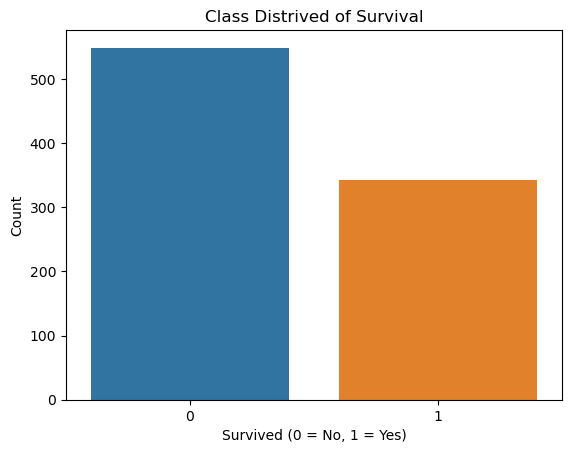

In [8]:
# Observe class distribution of the target variable (Survived)
plt.figure()
sns.countplot(x="Survived",data=df)
plt.title("Class Distrived of Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

Observation
- The dataset is imbalanced
- More passengers did not survive than survived
- Class imbalance must be considered during model evaluation

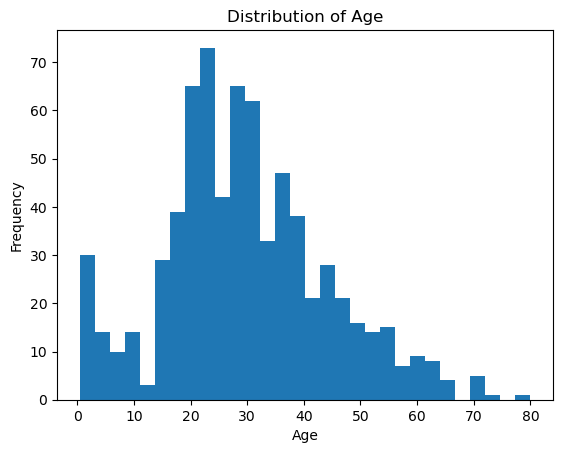

In [9]:
# Histogram of Age
plt.figure()
plt.hist(df["Age"].dropna(),bins=30)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

Observation
- Majority of passengers are between 20–40 years
- Presence of outliers at higher ages


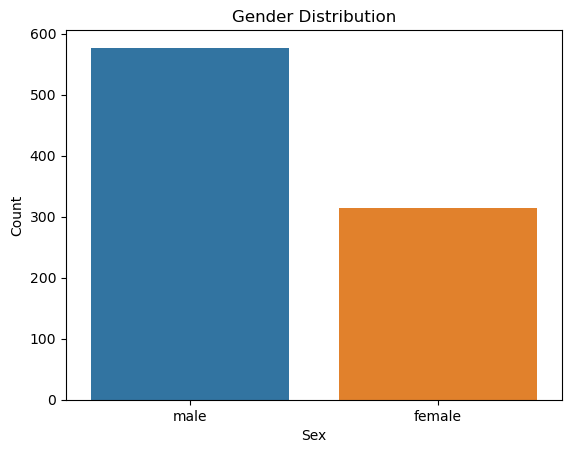

In [10]:
# Bar chart for Sex and Pclass
plt.figure()
sns.countplot(x="Sex",data=df)
plt.title("Gender Distribution")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

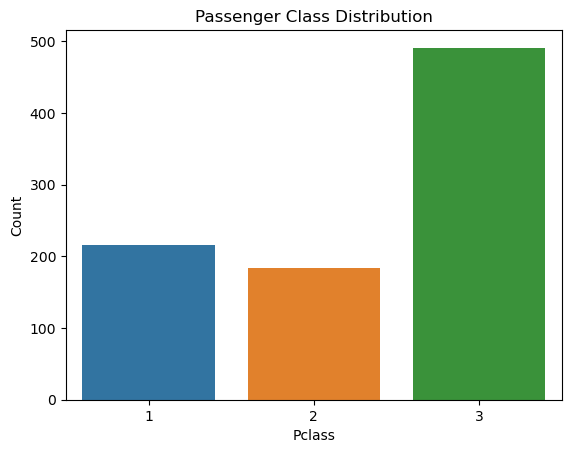

In [11]:
plt.figure()
sns.countplot(x="Pclass",data=df)
plt.title("Passenger Class Distribution")
plt.xlabel("Pclass")
plt.ylabel("Count")
plt.show()

Observation
- More male passengers than female
- Majority of passengers belonged to **3rd class**
- Passenger class may strongly influence survival

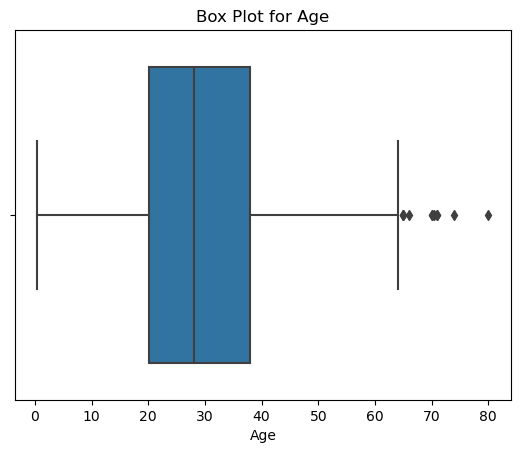

In [12]:
# Identify skewness and outliers

plt.figure()
sns.boxplot(x=df["Age"])
plt.title("Box Plot for Age")
plt.show()

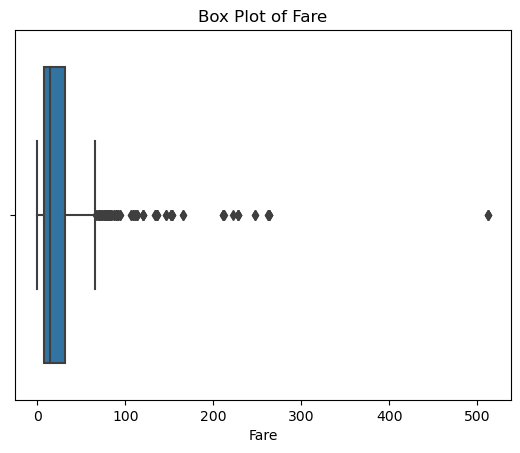

In [13]:
plt.figure()
sns.boxplot(x=df["Fare"])
plt.title("Box Plot of Fare")
plt.show()

Observation
- Fare contains significant outliers
- Age has fewer extreme outliers
- Fare distribution is highly skewed


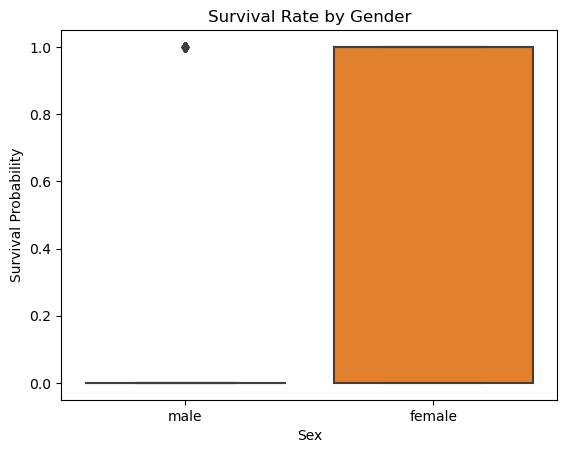

In [14]:
# Bivariate Analysis
# Survival vs Gender

plt.figure()
sns.boxplot(x="Sex" ,y="Survived", data=df)
plt.title("Survival Rate by Gender")
plt.ylabel("Survival Probability")
plt.show()

Observation
- Females had a much higher survival rate
- Gender is a strong predictor of survival


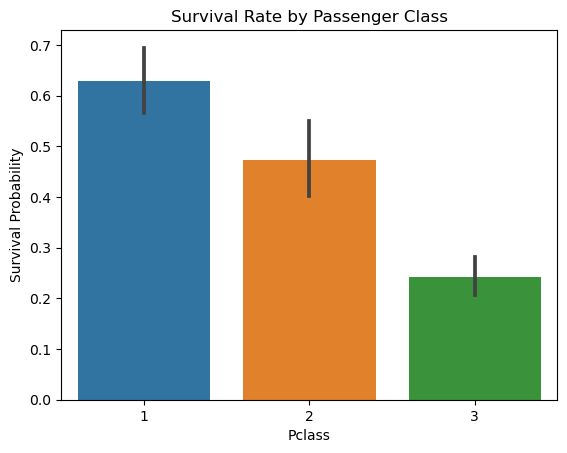

In [15]:
plt.figure()
sns.barplot(x="Pclass", y="Survived", data=df)
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Probability")
plt.show()


### Observation
- 1st class passengers had the highest survival rate
- Survival rate decreases as passenger class decreases
- Passenger class is a critical feature


### Part 3 : Missing Value Analysis

Missing value analysis helps identify incomplete data and decide
appropriate strategies to handle them without losing important information.

Improper handling of missing values can lead to biased or incorrect models.

In [16]:
# Count Missing Values per Column

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Observation
- Age, Cabin, and Embarked columns contain missing values
- Cabin has a large number of missing entries


In [17]:
# Calculate percentage of missing values.

missing_values = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    "Missing Values" : df.isnull().sum(),
    "Percentage %" : missing_values
})
missing_df[missing_df["Missing Values"] > 0]

,Missing Values,Percentage %
Age,177,19.865320
Cabin,687,77.104377
Embarked,2,0.224467


Observation
- Cabin has more than **75% missing values**
- Age has around **20% missing values**
- Embarked has less than **1% missing values**


In [18]:
# Replace missing Age with median

age_median = df["Age"].median()
df["Age"].fillna(age_median, inplace=True)

print("Missing values after imputation",df["Age"].isnull().sum())

Missing values after imputation 0


Observation
- Missing Age values have been successfully replaced with the median
- Median is robust to outliers compared to mean


In [19]:
# Replace missing Embarked with mode
df["Embarked"].value_counts()
embarked_mode = df["Embarked"].mode()[0]
df["Embarked"].fillna(embarked_mode, inplace=True)

print("Missing values after imputation"),df["Embarked"].isnull().sum()

Missing values after imputation


(None, 0)

Observation
- Missing Embarked values replaced with the most frequent category
- This preserves categorical consistency


### Part 4: Data Cleaning

Data cleaning removes irrelevant, redundant, and inconsistent data.
This step improves model efficiency and prevents noise from affecting predictions.

In [20]:
# Drop irrelevant columns 

df.drop(columns=["PassengerId","Name","Ticket","Cabin"],inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


**Observation**
- Irrelevant columns successfully removed
- Dataset now contains only meaningful features


In [21]:
# Check for duplicate records.

print("Duplicate Rows",df.duplicated().sum())

Duplicate Rows 116


**Observation**
- After removing these unique-identifying columns, many passengers now look identical across remaining columns that is why 166  is coming as output above.

In [22]:
# Unique Values in Categorical Columns

for col in df.select_dtypes(include="object").columns:
    print(f"{col}: {df[col].unique()}")

Sex: ['male' 'female']
Embarked: ['S' 'C' 'Q']


**Observation**
- Categorical values are consistent
- No spelling inconsistencies or unexpected categories found


### Part 5: Data Preprocessing

Preprocessing prepares the cleaned data for machine learning models
by converting categorical variables to numerical form and scaling features.

In [23]:
# Encoding Categorical Variables
# Convert Sex → numerical (0/1)

df["Sex"] = df["Sex"].map({"male":0,"female":1})
df["Sex"].head()

0    0
1    1
2    1
3    1
4    0
Name: Sex, dtype: int64

**Observation**
- Sex converted to binary numerical values
- Required for machine learning algorithms


In [24]:
# Embarked → one-hot encoding

df = pd.get_dummies(df,columns=["Embarked"], drop_first=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


**Observation**
- Embarked converted into multiple binary columns
- One-hot encoding avoids ordinal assumptions


In [29]:
# Identify Numerical Columns for Scaling

from sklearn.preprocessing import StandardScaler
numerical_features = ["Age", "Fare", "SibSp", "Parch"]


In [30]:
scaler = StandardScaler()
df[numerical_features] = scaler.fit_transform(df[numerical_features])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,0.827377,0,-0.565736,0.432793,-0.473674,-0.502445,False,True
1,1,-1.566107,1,0.663861,0.432793,-0.473674,0.786845,False,False
2,1,0.827377,1,-0.258337,-0.474545,-0.473674,-0.488854,False,True
3,1,-1.566107,1,0.433312,0.432793,-0.473674,0.420730,False,True
4,0,0.827377,0,0.433312,-0.474545,-0.473674,-0.486337,False,True


**Observation**
- Numerical features are standardized (mean = 0, std = 1)
- Dataset is now suitable for machine learning models


## Part 6: Final Dataset Preparation

In this step, the fully cleaned and preprocessed dataset is separated into:
- **Features (X)**: Input variables for the model
- **Target variable (y)**: Output variable to be predicted

This prepares the dataset for machine learning algorithms.


In [31]:
# Separate Target Variable (y)

y = df["Survived"]
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

**Observation**
- **Survived** is the target variable
- It represents a binary classification problem:
  - 0 → Did not survive
  - 1 → Survived


In [32]:
# Separate Features (X)

X = df.drop(columns=["Survived"])
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0.827377,0,-0.565736,0.432793,-0.473674,-0.502445,False,True
1,-1.566107,1,0.663861,0.432793,-0.473674,0.786845,False,False
2,0.827377,1,-0.258337,-0.474545,-0.473674,-0.488854,False,True
3,-1.566107,1,0.433312,0.432793,-0.473674,0.420730,False,True
4,0.827377,0,0.433312,-0.474545,-0.473674,-0.486337,False,True


**Observation**
- All remaining columns are input features
- Features include numerical and encoded categorical variables
- Dataset is now model-ready


In [34]:
# Display Final Processed Dataset

print("Final Feature Dataset Shape:", X.shape)
print("Final Target Shape:", y.shape)

display(df.head())


Final Feature Dataset Shape: (891, 8)
Final Target Shape: (891,)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,0.827377,0,-0.565736,0.432793,-0.473674,-0.502445,False,True
1,1,-1.566107,1,0.663861,0.432793,-0.473674,0.786845,False,False
2,1,0.827377,1,-0.258337,-0.474545,-0.473674,-0.488854,False,True
3,1,-1.566107,1,0.433312,0.432793,-0.473674,0.420730,False,True
4,0,0.827377,0,0.433312,-0.474545,-0.473674,-0.486337,False,True


**Summary**

- All missing values have been handled
- Irrelevant columns removed
- Categorical variables encoded
- Numerical features scaled
- Dataset is clean, consistent, and suitable for ML models
